<a href="https://colab.research.google.com/github/swirita/Prediction-of-Product-Sales/blob/main/Prediction_of_Product_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediction of Product Sales

Siwar Ehwass

## Overview

>
> - The company's objective was to **accurately predict item outlet sales** to support inventory planning and business decision-making.
>
> - Three models were evaluated: **Linear Regression**, **Default Random Forest**, and **Tuned Random Forest**.
>
> - **Linear Regression** provided a strong baseline with good generalization (**R² = 0.56**).
>
> - The **Default Random Forest** suffered from overfitting, performing well on the training data but worse on the test data (**R² = 0.55**).
>
> - After hyperparameter tuning, the **Random Forest** achieved the best performance (**R² = 0.60**) with improved generalization and lower prediction errors.
>
> - Overall, the **Tuned Random Forest** best met the company's objective by providing the most accurate and reliable sales predictions for unseen data.
>

## Data Dictionary

| **Variable Name** | **Description** |
|-------------------|-----------------|
| **Item_Identifier** | Unique identifier for each product. |
| **Item_Weight** | Weight of the product. |
| **Item_Fat_Content** | Indicates whether the product is **Low Fat** or **Regular**. |
| **Item_Visibility** | Percentage of the store's display area allocated to the product. |
| **Item_Type** | Category to which the product belongs. |
| **Item_MRP** | Maximum Retail Price (MRP) of the product. |
| **Outlet_Identifier** | Unique identifier for each store. |
| **Outlet_Establishment_Year** | Year in which the store was established. |
| **Outlet_Size** | Size of the outlet (Small, Medium, or High). |
| **Outlet_Location_Type** | Location tier of the outlet (Tier 1, Tier 2, or Tier 3). |
| **Outlet_Type** | Type of outlet (e.g., Grocery Store or Supermarket). |
| **Item_Outlet_Sales** | Sales of the product in a specific outlet. **This is the target variable to be predicted.** |

## Load and Inspect Data

### Imports

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import set_config

set_config(transform_output='pandas')

### Loading Data

In [2]:
path='https://docs.google.com/spreadsheets/d/e/2PACX-1vR6AvAZumX2EE8diEPYfNdktYpa8cELog1Iv_SL7EIFj_DIVxnGwq5liujvJ1GTQry9NDkFsISbeWaE/pub?output=csv'
df=pd.read_csv(path)
# check information about the dataset
df.info()
# check first five rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


> What we can interpret from this:
>  1) We have 8523 rows, and 12 columns.
>  2) `Item_Identifier` & `Outlet_Identifier` are merely identifiers, they do not help with model training.
>  3) There is null values in `Item_Weight` & `Outlet_Size`.
>  4) `Outlet_Size`, `Outlet_Location_Type` are Ordinal Features.

## Data Cleaning

### Dropping Identifiers

In [7]:
df= df.drop(columns=['Item_Identifier','Outlet_Identifier'])

### Duplicated Rows

In [4]:
# check for duplicated data
df.duplicated().sum()

np.int64(0)

- there are no duplicated values



### Unique Identifiers

In [8]:
# check for unique percentage
df.nunique() / len(df) * 100

,0
Item_Weight,4.869178
Item_Fat_Content,0.058665
Item_Visibility,92.455708
Item_Type,0.187727
Item_MRP,69.670304
Outlet_Establishment_Year,0.105597
Outlet_Size,0.035199
Outlet_Location_Type,0.035199
Outlet_Type,0.046932
Item_Outlet_Sales,40.983222


> **Notes:**
> - It is noticeable that `Item_Visibility` and `Item_MRP` have really high
> variance, however we are not going to drop them as they are useful for training
> the model later.
>
>
> - As expected for the other features, the variation is fairly well and there is no high cardinality features.

### Data Inconsistencies

In [9]:
# filter out both num and object features
num_cols=df.select_dtypes('number').columns # select numbers
cat_cols=df.select_dtypes('object').columns # select objects

# loop through each one's value counts (objects)
for col in cat_cols:
    print(f'Value counts of {col}:\n {df[col].value_counts(dropna=False)} \n')

Value counts of Item_Fat_Content:
 Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64 

Value counts of Item_Type:
 Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64 

Value counts of Outlet_Size:
 Outlet_Size
Medium    2793
NaN       2410
Small     2388
High       932
Name: count, dtype: int64 

Value counts of Outlet_Location_Type:
 Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64 

Value counts of Outlet_Type:
 O

> What we can get from this:
> 1) For `Item_Fat_Content` feature:
>   - Typos and Inconsistent values (LF, Low Fat, low fat)
> 2) For `Outlet_Size` Feature:
>   - It has 2410 null values.
>   - It is an Ordinal Feature (Small, Medium, High).
> 3) For `Outlet_Location_Type` Feature:
>   - It is an Ordinal Feature (Tier 1, Tier 2, Tier 3).`


In [10]:
# check describe for numbers (loop)
for col in num_cols:
    print(f'Describe for {col}\n {df[col].describe()}')

Describe for Item_Weight
 count    7060.000000
mean       12.857645
std         4.643456
min         4.555000
25%         8.773750
50%        12.600000
75%        16.850000
max        21.350000
Name: Item_Weight, dtype: float64
Describe for Item_Visibility
 count    8523.000000
mean        0.066132
std         0.051598
min         0.000000
25%         0.026989
50%         0.053931
75%         0.094585
max         0.328391
Name: Item_Visibility, dtype: float64
Describe for Item_MRP
 count    8523.000000
mean      140.992782
std        62.275067
min        31.290000
25%        93.826500
50%       143.012800
75%       185.643700
max       266.888400
Name: Item_MRP, dtype: float64
Describe for Outlet_Establishment_Year
 count    8523.000000
mean     1997.831867
std         8.371760
min      1985.000000
25%      1987.000000
50%      1999.000000
75%      2004.000000
max      2009.000000
Name: Outlet_Establishment_Year, dtype: float64
Describe for Item_Outlet_Sales
 count     8523.000000
mean

> There is no unrealistic value in any feature.
> However, in `Item_Visibility` Some items have visiility of zero, which is unrealistic, going to impute it with a null value.

#### Handling `Item_Fat_Content

In [11]:
# fix inconsistent values
df['Item_Fat_Content']=df['Item_Fat_Content'].replace({'LF': 'Low Fat',
                                       'low fat': 'Low Fat',
                                       'reg' : 'Regular'})
# check value counts again
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


#### Handling `Item_Visibility`

In [16]:
# Impute all values thats equal to zero with np.nan
df.loc[df['Item_Visibility']==0, 'Item_Visibility'] = np.nan

### Missing Values

> We are going to impute missing values in this step with a null value using `np.nan`, so later in model preprocessing we can impute without causing data leakage.
>
> The Features with null values are:
> - `Item_Visibility`, 526 null value (impute with mean or median)
> - `Item_Weight`, 1463 null values (impute with mean or median)
> - `Outlet_Size`, 2410 missing values, impute with constant 'MISSING' or Most frequent.
>

In [17]:
# see columns and rows where NaN is present in df
df.isna().sum()

,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,526
Item_Type,0
Item_MRP,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0
Outlet_Type,0
Item_Outlet_Sales,0


#### Inspecting Outlet Size

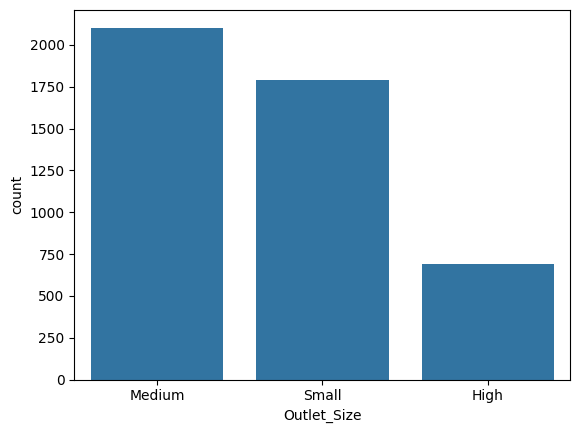

In [ ]:
ax=sns.countplot(data=df, x='Outlet_Size')

> - This graph shows that there are over 2000 Medium and Small Outlets Size while there are less than 1000 High Outlet size.
>
> - Since Outlet_Size is a categorical feature with a large percentage of missing values (~28%):
>  - dropping rows would result in significant data loss.
>  - Filling with the most frequent category could introduce bias into the distribution.
>  - Therefore, replacing missing values with "MISSING" is the most appropriate strategy because it preserves the data

#### Inspecting Item Weight

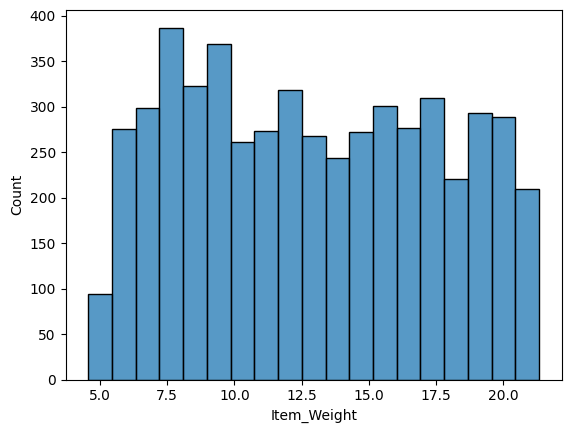

In [ ]:
ax = sns.histplot(data=df,x='Item_Weight')

> - Median is preferred because it is less affected by outliers and preserves the distribution better than using -1 or dropping rows.
>
> - Since `Item_Weight` is a numeric feature, missing values were filled using the median because it is less affected by outliers and helps preserve the overall distribution of the data.

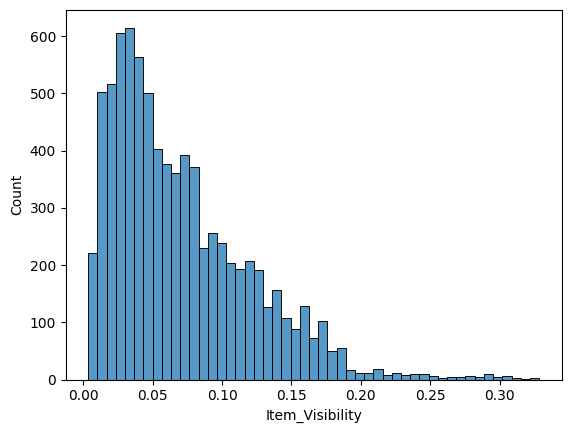

In [20]:
ax = sns.histplot(data=df,x='Item_Visibility')

> - Median is preferred because it is less affected by outliers and preserves the distribution better than using -1 or dropping rows.
>
> - Since `Item_Visibility` is a numeric feature, missing values were filled using the median because it is less affected by outliers and helps preserve the overall distribution of the data.

### Describe Numeric Data
- min, max, mean

In [19]:
# get numeric columns from df
num_cols=df.select_dtypes('number').columns

# use the describe method and filter using .loc() on df
df[num_cols].describe().loc[['min','max','mean']]

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
min,4.555000,0.003575,31.290000,1985.000000,33.290000
max,21.350000,0.328391,266.888400,2009.000000,13086.964800
mean,12.857645,0.070482,140.992782,1997.831867,2181.288914


## Feature Inspection
- Exploratory Visuals & Analysis

### Data Distribution

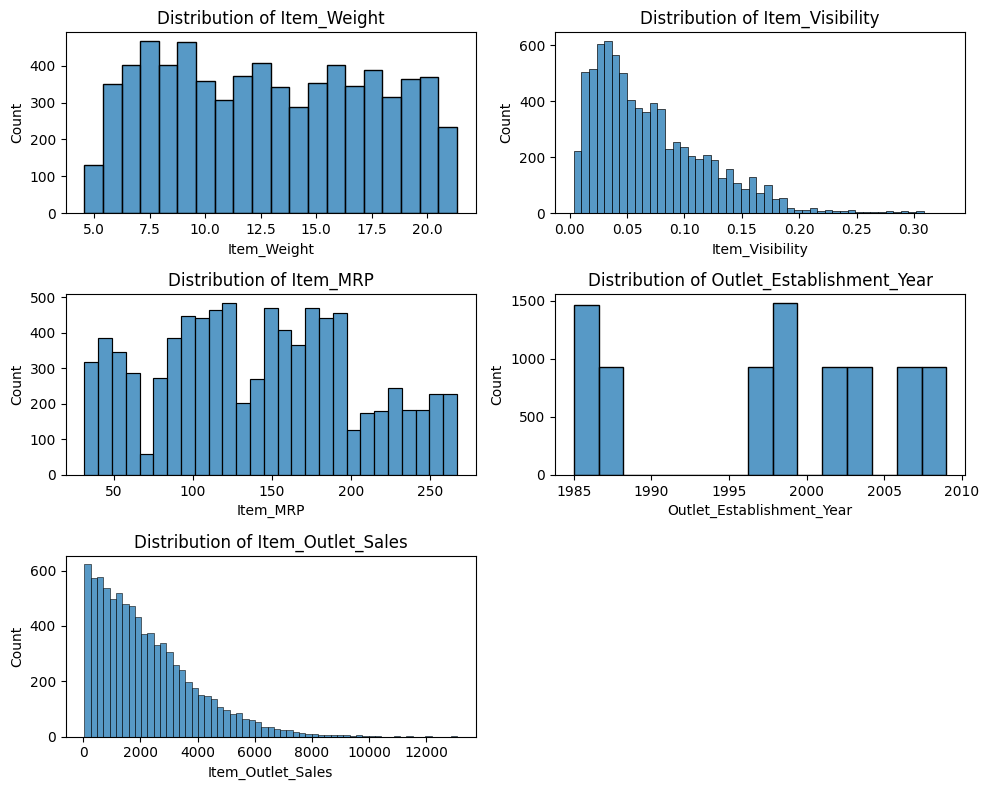

In [31]:
# select numeric columns
num_cols = df.select_dtypes('number').columns

# create 2x2 grid
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))

# convert axes to a 1D array
axes = axes.flatten()


# loop through each numeric column
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

# Remove empty plots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout()

> **Distribution Analysis**
>
> - **Item_Weight:** The values are fairly evenly distributed with no significant skew or extreme outliers, indicating a balanced range of product weights.
>
> - **Item_Visibility:** The distribution is positively (right) skewed, meaning most products have low visibility while only a few have high visibility. It is also recommended to check for zero values, as they may represent missing data.
>
> - **Item_MRP:** The distribution is multimodal, showing several price groups rather than a single peak. This suggests products are sold at different pricing tiers.
>
> - **Outlet_Establishment_Year:** The feature is discrete, with outlets established only in specific years, which explains the gaps between bars.
>
> - **Item_Outlet_Sales:** The target variable is positively skewed, indicating that most products generate relatively low sales, while only a small number achieve very high sales.
>

### Boxplot for numeric columns

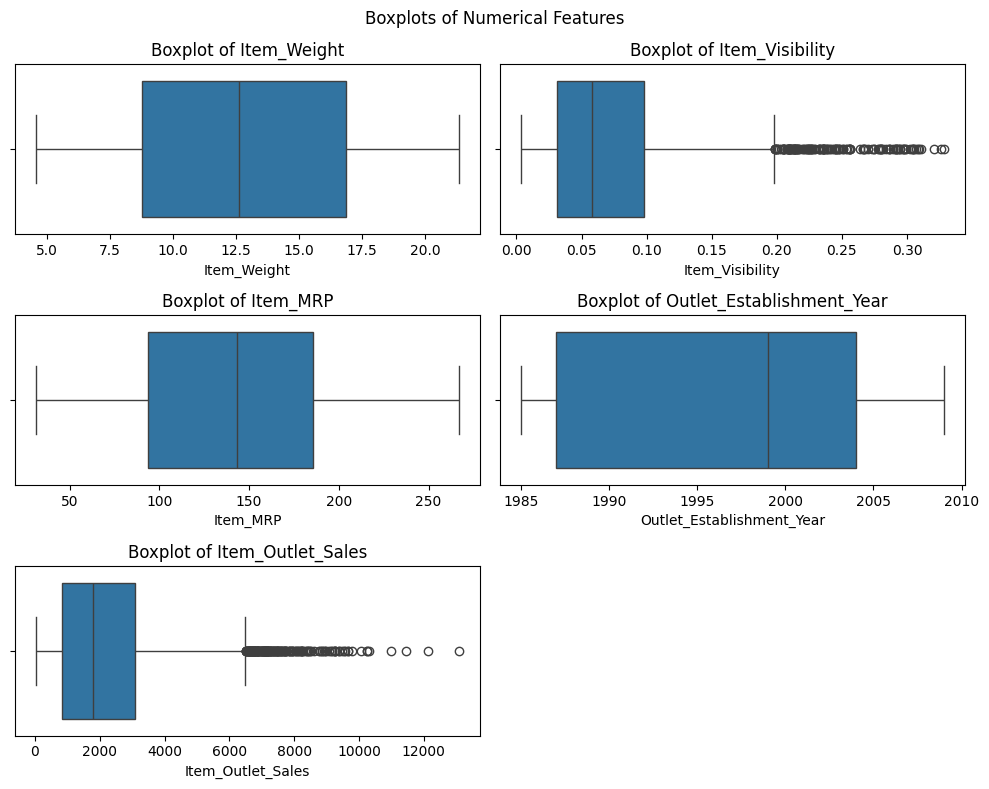

In [32]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 8))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}", fontsize=12)
    axes[i].set_xlabel(col)

# Remove empty plots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Boxplots of Numerical Features")
fig.tight_layout();

> **Boxplot Analysis**
>
> - **Item_Weight:** No significant outliers are present, indicating that the feature has a consistent range of values.
>
> - **Item_Visibility:** Several high-value outliers are observed, suggesting that a small number of products have unusually high visibility compared to the majority.
>
> - **Item_MRP:** No noticeable outliers are present, indicating that product prices are generally within a reasonable range.
>
> - **Outlet_Establishment_Year:** No outliers are detected since the feature contains only a limited number of discrete establishment years.
>
> - **Item_Outlet_Sales:** Many upper outliers are present, showing that a few products achieve exceptionally high sales compared to most products.
>

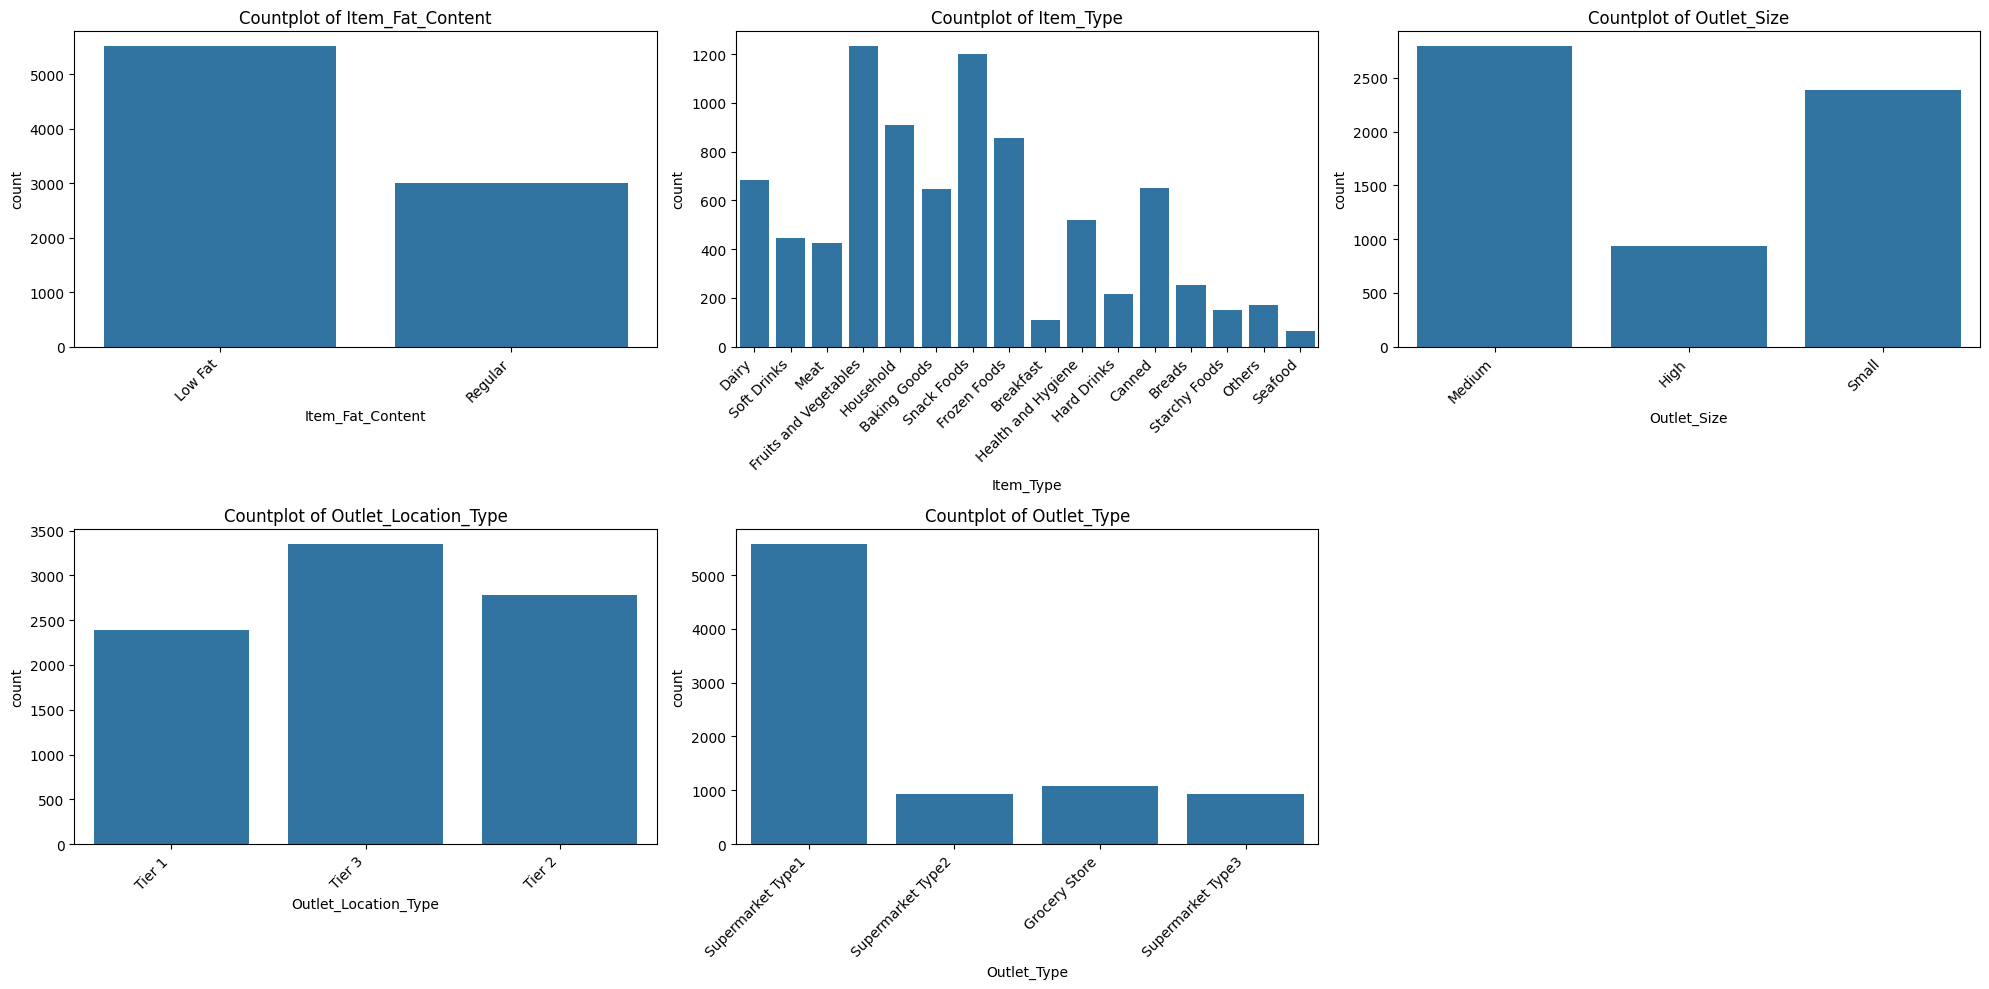

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])

    axes[i].set_title(f"Countplot of {col}")
    axes[i].tick_params(axis='x', labelrotation=45)

    # Right-align labels
    for label in axes[i].get_xticklabels():
        label.set_ha('right')
# Remove empty plots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

fig.tight_layout();

> **Categorical Feature Analysis**
>
> - **Item_Fat_Content:** Low Fat products are considerably more common than Regular products, indicating an imbalanced distribution.
>
> - **Item_Type:** Fruits and Vegetables and Snack Foods are the most frequent product categories, while Seafood and Breakfast are the least common.
>
> - **Outlet_Size:** Medium outlets are the most common, followed by Small outlets, whereas High-sized outlets are the least represented.
>
> - **Outlet_Location_Type:** Tier 3 has the highest number of outlets, followed by Tier 2, while Tier 1 has the fewest.
>
> - **Outlet_Type:** Supermarket Type1 dominates the dataset, whereas Grocery Store, Supermarket Type2, and Supermarket Type3 have significantly fewer observations.
>


### Correlation Heatmap


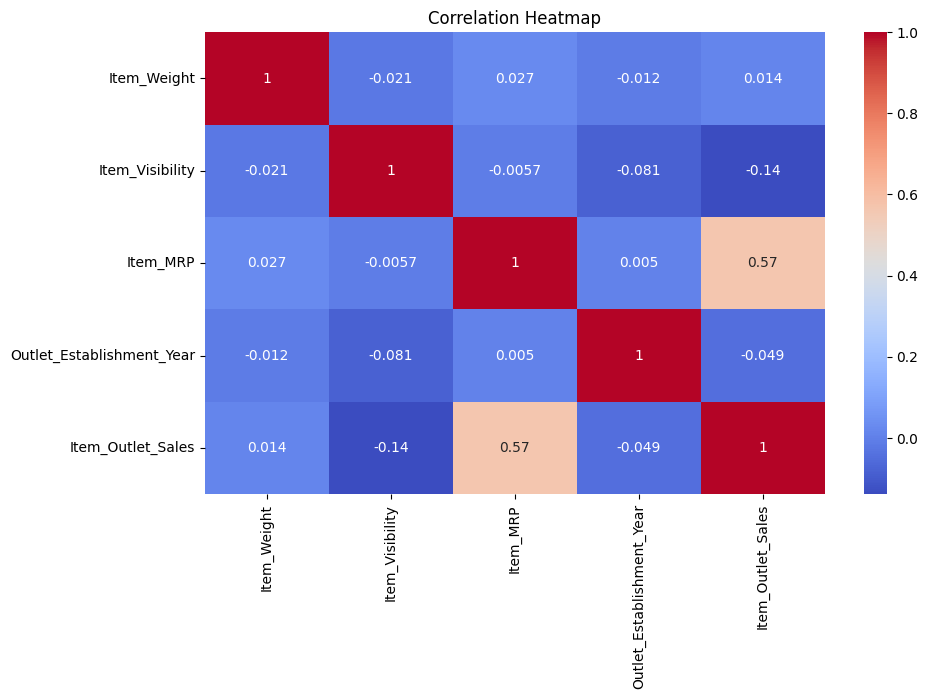

In [35]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,6))
ax = sns.heatmap(corr, annot=True, cmap='coolwarm')
ax.set_title("Correlation Heatmap");

> **Correlation Analysis**
>
> - **Item_MRP** has the strongest positive correlation with **Item_Outlet_Sales** (**0.57**), indicating that higher-priced products tend to generate higher sales.
>
> - **Item_Visibility** has a weak negative correlation with **Item_Outlet_Sales** (**-0.14**), suggesting that visibility has little linear relationship with sales.
>
> - **Item_Weight** (**0.01**) and **Outlet_Establishment_Year** (**-0.05**) have negligible correlations with the target, indicating they are weak predictors individually.
>
> - Overall, there is **no strong multicollinearity** among the numerical features, as the correlations between independent variables are all close to zero.
>

### Regression Plot: Maximum Retail Price & Item Outlet Sales

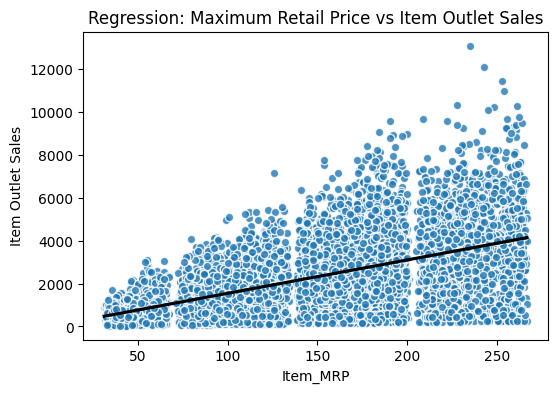

In [36]:
plt.figure(figsize=(6,4))
line_kws = dict(color='black')
scatter_kws = dict(edgecolor='white')

ax = sns.regplot(
    data=df,
    x='Item_MRP',
    y='Item_Outlet_Sales',
    line_kws=line_kws,
    scatter_kws=scatter_kws
)

ax.set(
    xlabel="Item_MRP",
    ylabel="Item Outlet Sales",
    title="Regression: Maximum Retail Price vs Item Outlet Sales"
);

> - There is a positive relationship between Maximum Retail Price and Item Outlet Sales. As retail price increases, sales tend to increase as well.

### OutletType vs Sales

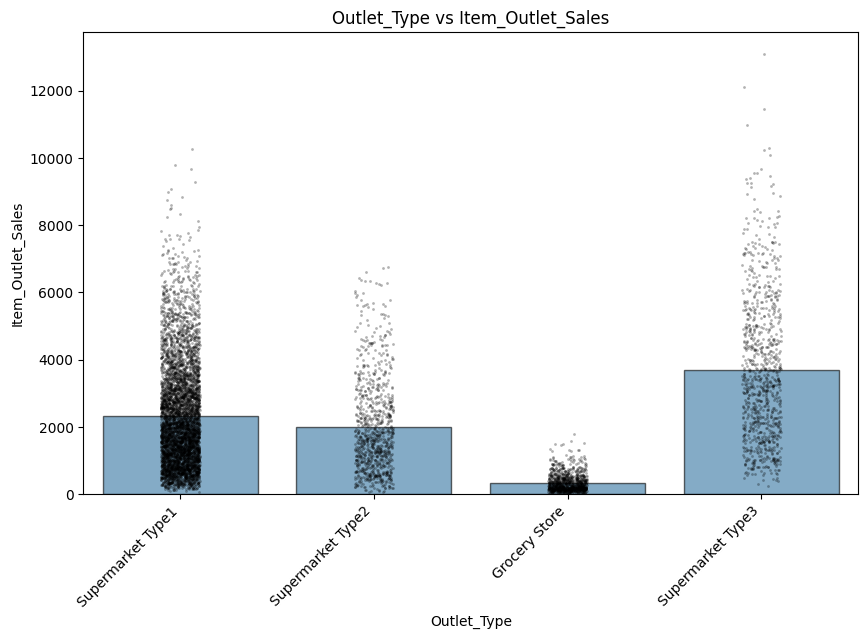

In [37]:

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Outlet_Type",
    y="Item_Outlet_Sales",
    errorbar=None,
    alpha=0.6,
    edgecolor="black"
)

sns.stripplot(
    data=df,
    x="Outlet_Type",
    y="Item_Outlet_Sales",
    color="black",
    alpha=0.3,
    size=2,
    jitter=True
)

plt.title("Outlet_Type vs Item_Outlet_Sales")
plt.xticks(rotation=45, ha="right");

> **Outlet Type vs Item Outlet Sales Analysis**
>
> - **Supermarket Type3** records the highest sales overall, with the largest median sales and the highest maximum values.
>
> - **Supermarket Type1** also achieves relatively high sales but with greater variability across products.
>
> - **Supermarket Type2** has moderate sales, generally lower than Supermarket Type1 and Type3.
>
> - **Grocery Stores** generate the lowest sales, with most observations concentrated at the lower end of the sales range.
>
> - Overall, **Outlet_Type** appears to have a significant influence on **Item_Outlet_Sales**, making it a potentially important feature for predicting sales.
>

## Preprocessing

In [40]:
# split data
y = df['Item_Outlet_Sales']
X = df.drop(columns=['Item_Outlet_Sales', 'Item_Weight', 'Outlet_Establishment_Year'])  # dropped Outlet_Establishment_Year, Item_Weight , no correlation to target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# ordinal category orders
size_order = ['MISSING', 'Small', 'Medium', 'High']
location_order = ['Tier 1', 'Tier 2', 'Tier 3']

ord_cols = ['Outlet_Size', 'Outlet_Location_Type']

# ordinal pipeline
ord_pipe = make_pipeline(
    SimpleImputer(strategy='constant', fill_value='MISSING'),  # fill missing humidity with 'MISSING' to avoid bias
    OrdinalEncoder(categories=[size_order, location_order]),
    StandardScaler()
)

ord_tuple = ('Ordinal', ord_pipe, ord_cols)

# Nominal Features
ohe_cols = X_train.select_dtypes('object').drop(columns=ord_cols).columns

# drop first to avoid multicollinearity
ohe_tuple = ('Categorical', OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first') , ohe_cols)

# Numbers pipe
num_cols= X_train.select_dtypes('number').columns
# Item_Visibility's 0s are now replaced with np.nan before this pipeline step
num_pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler()) # fill with median
num_tuple = ('Numeric', num_pipe, num_cols)

preprocessor = ColumnTransformer(
  [num_tuple, ord_tuple, ohe_tuple],
  verbose_feature_names_out=False
)

In [43]:
# Model Evaluation Function
def regression_metrics(y_true, y_pred, label='', verbose = True, output_dict=False):
  mae = mean_absolute_error(y_true, y_pred)
  mse = mean_squared_error(y_true, y_pred)
  rmse = mse ** 0.5
  r_squared = r2_score(y_true, y_pred)
  if verbose == True:
    header = "-"*60
    print(header, f"Regression Metrics: {label}", header, sep='\n')
    print(f"- MAE = {mae:,.3f}")
    print(f"- MSE = {mse:,.3f}")
    print(f"- RMSE = {rmse:,.3f}")
    print(f"- R^2 = {r_squared:,.3f}")
  if output_dict == True:
      metrics = {'Label':label, 'MAE':mae,
                 'MSE':mse, 'RMSE':rmse, 'R^2':r_squared}
      return metrics

def evaluate_regression(reg, X_train, y_train, X_test, y_test, verbose = True,
                        output_frame=False):
  y_train_pred = reg.predict(X_train)

  results_train = regression_metrics(y_train, y_train_pred, verbose = verbose,
                                     output_dict=output_frame,
                                     label='Training Data')
  print()
  y_test_pred = reg.predict(X_test)
  results_test = regression_metrics(y_test, y_test_pred, verbose = verbose,
                                  output_dict=output_frame,
                                    label='Test Data' )

  if output_frame:
    results_df = pd.DataFrame([results_train,results_test])
    results_df = results_df.set_index('Label')
    results_df.index.name=None
    return results_df.round(3)

## Model: Linear Regression

In [44]:
# linear regression
linreg_pipe = make_pipeline(preprocessor, LinearRegression())

# Fit on raw training data
linreg_pipe.fit(X_train, y_train)
evaluate_regression(linreg_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 847.405
- MSE = 1,300,280.485
- RMSE = 1,140.298
- R^2 = 0.561

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 805.734
- MSE = 1,198,985.702
- RMSE = 1,094.982
- R^2 = 0.565


> **Linear Regression Performance**
>
> - The model achieved an **R² of 0.56**, explaining about **56% of the variation** in item sales.
>
> - The **MAE (~806)** indicates that predictions are, on average, about **806 sales units** away from the actual values.
>
> - Training and test metrics are very similar, indicating **good generalization** with **no significant overfitting**.
>

## Model: Random Forest

In [45]:
rf = RandomForestRegressor(random_state=42)
rf_pipe = make_pipeline(preprocessor, rf)

rf_pipe.fit(X_train, y_train)
evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 301.746
- MSE = 191,217.377
- RMSE = 437.284
- R^2 = 0.935

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 777.759
- MSE = 1,255,634.715
- RMSE = 1,120.551
- R^2 = 0.545


> **Random Forest Performance**
>
> - The model achieved an **R² of 0.55** on the test set, explaining about **55% of the variation** in item sales.
>
> - Although it performed extremely well on the training data (**R² = 0.94**), its performance dropped on the test set, indicating **overfitting**.
>
> - Overall, the default Random Forest **did not outperform** the Linear Regression model on unseen data.
>

### Tuning with GridCV

In [ ]:
params = {
    'randomforestregressor__max_depth': [None,5, 10, 15, 20],
    'randomforestregressor__n_estimators': [ 100, 150, 200, 300, 500],
    'randomforestregressor__min_samples_leaf': [1, 2, 4,6],
    'randomforestregressor__max_features': ['sqrt', 'log2', None],
    'randomforestregressor__oob_score': [True, False],
    'randomforestregressor__min_samples_split': [2, 5, 10]
}

# 5x5x4x3x2x3 = 1800 combinations x 3 folds = 5400 fits

gridsearch = GridSearchCV(rf_pipe, params, n_jobs=-1, cv=3, verbose=1)
gridsearch.fit(X_train, y_train)

print('\n',gridsearch.best_params_,'\n')

# Best model
best_rf = gridsearch.best_estimator_
evaluate_regression(best_rf, X_train, y_train, X_test, y_test)

Fitting 3 folds for each of 1800 candidates, totalling 5400 fits

 {'randomforestregressor__max_depth': 5, 'randomforestregressor__max_features': None, 'randomforestregressor__min_samples_leaf': 2, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 100, 'randomforestregressor__oob_score': True} 

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 755.505
- MSE = 1,152,234.495
- RMSE = 1,073.422
- R^2 = 0.611

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 728.641
- MSE = 1,096,798.476
- RMSE = 1,047.281
- R^2 = 0.602


In [46]:
rf = RandomForestRegressor(random_state=42,
                           max_depth=5, max_features=None,
                           min_samples_leaf=2,
                           n_estimators=100,
                           oob_score=True)
rf_pipe = make_pipeline(preprocessor, rf)

rf_pipe.fit(X_train, y_train)
score= evaluate_regression(rf_pipe, X_train, y_train, X_test, y_test)

------------------------------------------------------------
Regression Metrics: Training Data
------------------------------------------------------------
- MAE = 749.348
- MSE = 1,125,490.497
- RMSE = 1,060.891
- R^2 = 0.620

------------------------------------------------------------
Regression Metrics: Test Data
------------------------------------------------------------
- MAE = 727.639
- MSE = 1,096,800.553
- RMSE = 1,047.282
- R^2 = 0.602


> **Tuned Random Forest Performance**
>
> - The tuned model achieved an **R² of 0.60** on the test set, explaining about **60% of the variation** in item sales.
>
> - The gap between the training (**R² = 0.62**) and test (**R² = 0.60**) scores is small, indicating **good generalization** with **reduced overfitting**.
>
> - Overall, the tuned Random Forest **outperformed both** the default Random Forest and the Linear Regression model.
>

## **Evaluation**
###**Model Recommendation: Random Forest**

- I recommend the **Random Forest model** for deployment.
  - It outperforms Linear Regression on every test metric: lower MAE, MSE, RMSE, and higher R^2 (0.602 vs 0.567).
  - It shows minimal overfitting, with train/test R^2 nearly identical (0.611 vs 0.602), meaning it's genuinely capturing patterns, not memorizing.

###**R^2 for a non-technical stakeholder**

Our model explains about 60% of the variation in sales using the input features.

- Of every 10 "reasons" sales go up or down, our model accounts for about 6.
- The remaining 40% comes from factors not in our data such as market conditions, promotions, randomness.

###**Selected Metric: RMSE (Root Mean Squared Error)**

I chose RMSE since it's in the same units as sales, making it directly interpretable.
- Our Random Forest model has an RMSE of ~1,047 on test data where predictions are off by about 1,047 sales units on average.
- It penalizes large errors more, which matters since badly underestimating high-sale periods is costlier than small misses.


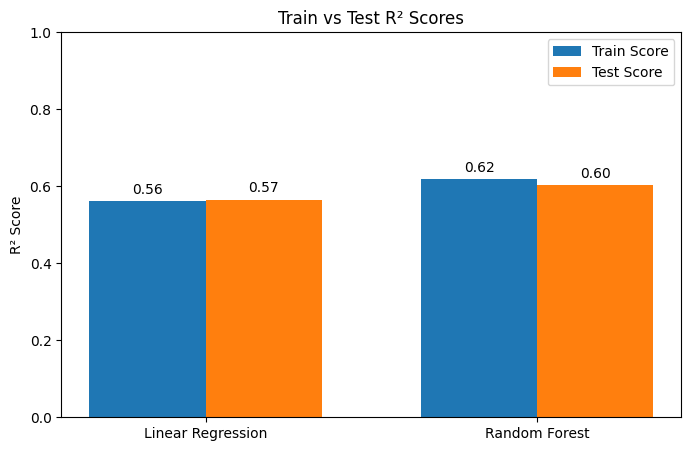

In [47]:
models = ['Linear Regression', 'Random Forest']

# Preprocess for Random Forest
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

train_scores = [linreg_pipe.score(X_train, y_train), rf.score(X_train_processed, y_train)]
test_scores = [linreg_pipe.score(X_test, y_test), rf.score(X_test_processed, y_test)]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))
bars1 = plt.bar(x - width/2, train_scores, width, label='Train Score')
bars2 = plt.bar(x + width/2, test_scores, width, label='Test Score')

plt.xticks(x, models)
plt.ylabel('R² Score')
plt.title('Train vs Test R² Scores')
plt.legend()
plt.ylim(0, 1)

plt.bar_label(bars1, fmt='%.2f', padding=3)
plt.bar_label(bars2, fmt='%.2f', padding=3);


###**Training vs. Test Performance: Overfitting/Underfitting Check**

The model is **not overfit**.
- Test performance is essentially equal to training performance.
- RMSE is slightly lower on test, R^2 drops slightly
- This means Random Forest generalizes well to unseen data.

- No sign of underfitting either, both models explain similar variance (R^2 ~0.56–0.61), suggesting this is near the practical ceiling for the current features.
- Next step to improve: better/more features rather than a more complex model.